# Лабораторная работа №2: Свёрточная нейронная сеть

Егорова Варвара Александровна, P3323, 408575

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)
print("Top-level files/folders:")
print(os.listdir(path))

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10
Top-level files/folders:
['translate.py', 'raw-img']


In [ ]:
data_dir = os.path.join(path, "raw-img")

folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
print("Папки классов на диске:", folders)
print("Количество классов:", len(folders))

translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "scoiattolo": "squirrel",
    "ragno": "spider"
}

classes_list = [cls for cls in folders if cls in translate]
print("Используемые классы:", classes_list)

Папки классов на диске: ['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']
Количество классов: 10
Используемые классы: ['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']


Папка с данными: /kaggle/input/animals10/raw-img
Содержимое: ['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']
Классы: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


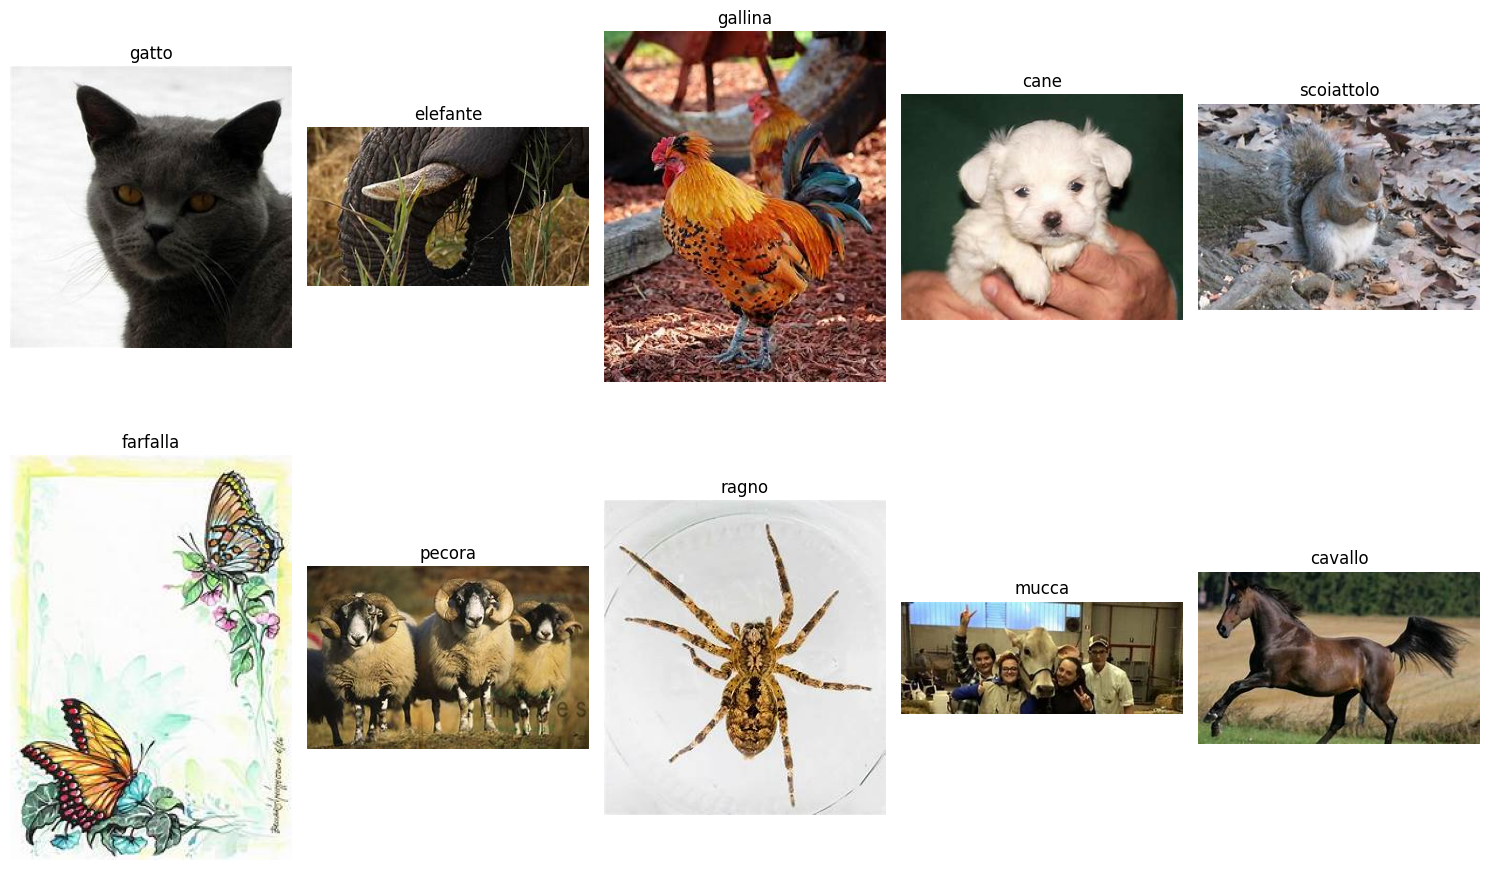

,class,count
8,cane,4863
6,ragno,4821
5,gallina,3098
0,cavallo,2623
9,farfalla,2112
7,mucca,1866
4,scoiattolo,1862
1,pecora,1820
3,gatto,1668
2,elefante,1446


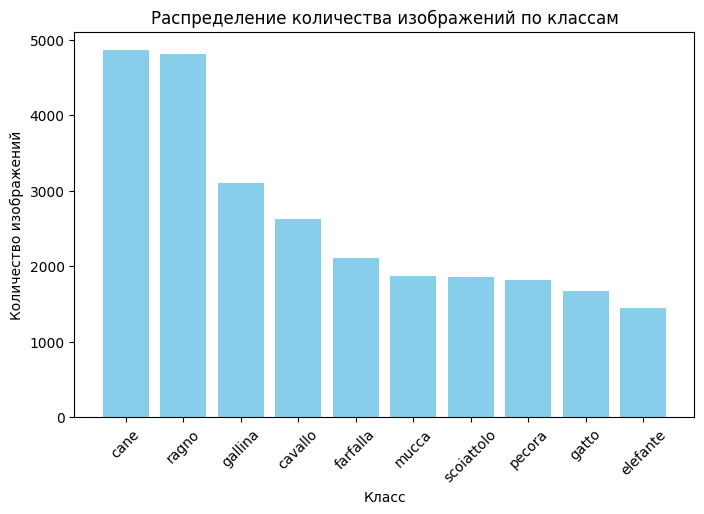

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

data_dir = os.path.join(path, "raw-img")

print("Папка с данными:", data_dir)
print("Содержимое:", os.listdir(data_dir))

classes = sorted(os.listdir(data_dir))
print("Классы:", classes)

plt.figure(figsize=(15, 10))

for i, cls in enumerate(random.sample(classes, 10)):
    cls_dir = os.path.join(data_dir, cls)
    imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if not imgs:
        print(f"В классе {cls} нет изображений, пропускаем")
        continue

    img_path = os.path.join(cls_dir, random.choice(imgs))
    img = mpimg.imread(img_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

class_counts = {}
for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

df_counts = pd.DataFrame(list(class_counts.items()), columns=["class", "count"]).sort_values("count", ascending=False)
display(df_counts)

plt.figure(figsize=(8,5))
plt.bar(df_counts["class"], df_counts["count"], color="skyblue")
plt.xticks(rotation=45)
plt.title("Распределение количества изображений по классам")
plt.xlabel("Класс")
plt.ylabel("Количество изображений")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training',
    classes=classes_list
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    classes=classes_list
)

class_indices_eng = {i: translate[name] for name, i in train_gen.class_indices.items()}
print("Индекс -> английское имя класса:", class_indices_eng)

Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.
Индекс -> английское имя класса: {0: 'horse', 1: 'sheep', 2: 'elephant', 3: 'cat', 4: 'squirrel', 5: 'chicken', 6: 'spider', 7: 'cow', 8: 'dog', 9: 'butterfly'}


### Создание и обучение модели

In [ ]:
from tensorflow import keras

model = keras.models.Sequential([
    keras.layers.InputLayer(shape=(128, 128, 3)),
    keras.layers.Conv2D(filters=6, kernel_size=3, strides=1,
                        padding='valid', activation='relu', use_bias=False),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=train_gen.num_classes,
                       activation='softmax', use_bias=False)
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 6)    │           162 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 23814)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       238,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,302 (930.87 KB)

 Trainable params: 238,302 (930.87 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 65s 97ms/step - accuracy: 0.3319 - loss: 2.0157 - val_accuracy: 0.4209 - val_loss: 1.6943
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - accuracy: 0.5235 - loss: 1.4157 - val_accuracy: 0.4539 - val_loss: 1.6280
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 46s 70ms/step - accuracy: 0.6517 - loss: 1.0827 - val_accuracy: 0.4350 - val_loss: 1.7443
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.7449 - loss: 0.8223 - val_accuracy: 0.4386 - val_loss: 1.7717
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.8143 - loss: 0.6337 - val_accuracy: 0.4499 - val_loss: 1.9238
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.8687 - loss: 0.4713 - val_accuracy: 0.4459 - val_loss: 2.0365
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - accuracy: 0.9107 - loss: 0.3490 - val_accuracy: 0.4392 - val_loss: 2.2120
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy: 0.9441 - loss: 0.2594 - 

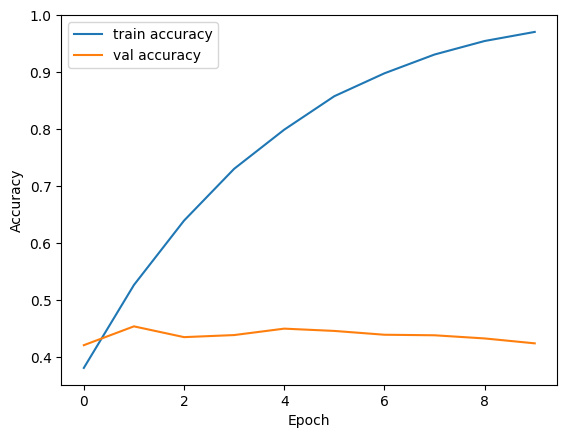

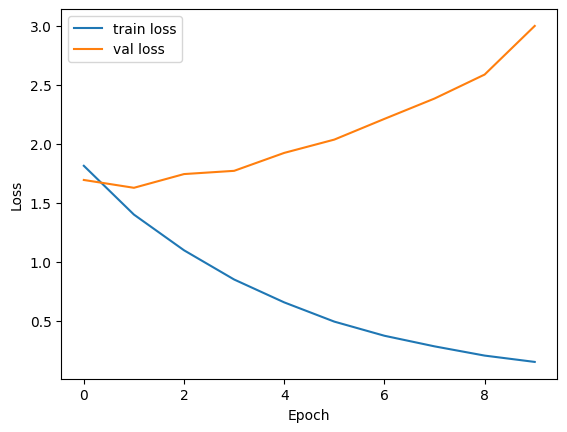

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"Базовая модель — точность на валидации: {val_acc:.3f}")

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.4249 - loss: 2.9490
Базовая модель — точность на валидации: 0.424


## Улучшение базовой модели

In [ ]:
model2 = keras.Sequential(
    [
        keras.layers.InputLayer(shape = (128, 128, 3)),
        keras.layers.Conv2D(filters = 32,
                            kernel_size = (3, 3),
                            activation = 'relu',
                            use_bias = True),
        keras.layers.MaxPooling2D(pool_size = (2, 2)),
        keras.layers.Conv2D(filters = 64,
                            kernel_size = (3, 3),
                            activation = 'relu',
                            use_bias = True),
        keras.layers.MaxPooling2D(pool_size = (2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dropout(rate = 0.5),
        keras.layers.Dense(10, activation = 'softmax'),
    ]
)

In [ ]:
model2.compile(
  optimizer = 'adam',
  loss='categorical_crossentropy',
  metrics=['accuracy'],
)

history = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.3598 - loss: 1.8327 - val_accuracy: 0.5319 - val_loss: 1.3738
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.6225 - loss: 1.1356 - val_accuracy: 0.5998 - val_loss: 1.2086
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - accuracy: 0.7170 - loss: 0.8473 - val_accuracy: 0.6135 - val_loss: 1.2182
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.7887 - loss: 0.6247 - val_accuracy: 0.6216 - val_loss: 1.2132
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - accuracy: 0.8451 - loss: 0.4705 - val_accuracy: 0.6151 - val_loss: 1.3314
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - accuracy: 0.8764 - loss: 0.3737 - val_accuracy: 0.6040 - val_loss: 1.4381
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.9000 - loss: 0.3009 - val_accuracy: 0.6225 - val_loss: 1.5065
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.9160 - loss: 0.2475 - 

In [ ]:
val_loss, val_acc = model2.evaluate(val_gen)
print(f"Улучшенная модель (2 сверточных слоя) — точность на валидации: {val_acc:.3f}")

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.6240 - loss: 1.8405
Улучшенная модель (2 сверточных слоя) — точность на валидации: 0.618


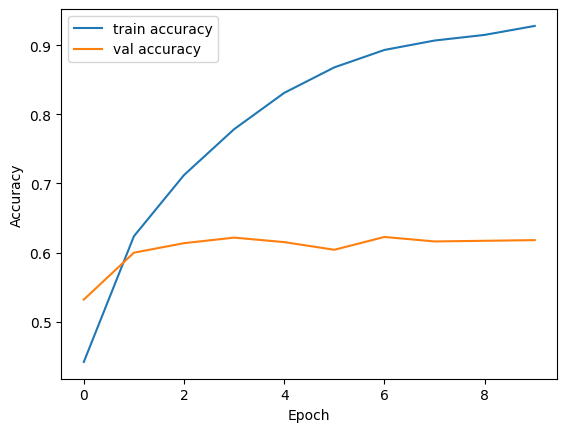

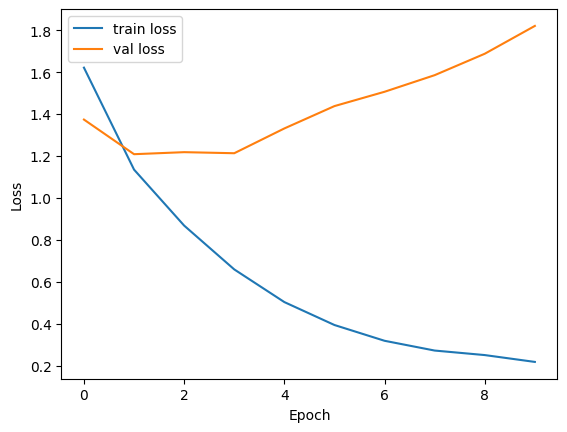

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Продолжаем улучшать

In [ ]:
from tensorflow import keras

model3 = keras.Sequential([
    keras.layers.InputLayer(shape=(128, 128, 3)),

    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model3.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

val_loss, val_acc = model3.evaluate(val_gen)
print(f"Улучшенная модель (3 сверточных слоя) — точность на валидации: {val_acc:.3f}")

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 55s 76ms/step - accuracy: 0.2866 - loss: 2.0122 - val_accuracy: 0.4564 - val_loss: 1.5575
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.4910 - loss: 1.4778 - val_accuracy: 0.5239 - val_loss: 1.3961
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.5639 - loss: 1.3033 - val_accuracy: 0.5644 - val_loss: 1.2791
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.6099 - loss: 1.1753 - val_accuracy: 0.5868 - val_loss: 1.2096
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - accuracy: 0.6416 - loss: 1.0797 - val_accuracy: 0.6191 - val_loss: 1.1349
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 46s 70ms/step - accuracy: 0.6774 - loss: 0.9815 - val_accuracy: 0.6273 - val_loss: 1.1150
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.7013 - loss: 0.9072 - val_accuracy: 0.6267 - val_loss: 1.1218
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.7234 - loss: 0.8417 - 

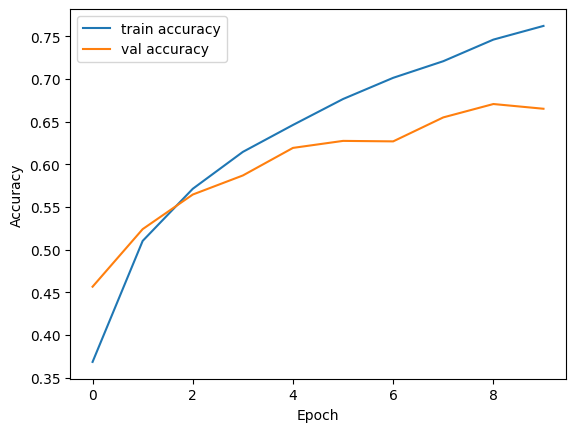

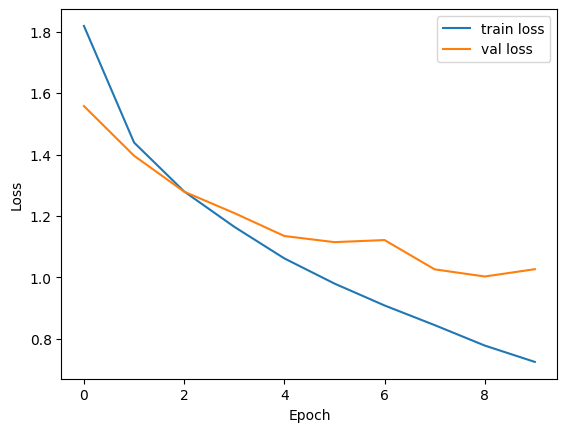

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Проверим модели на собственных картинках

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import pandas as pd
import os

class_indices = train_gen.class_indices

class_names = [None] * len(class_indices)
for class_name, index in class_indices.items():
    class_names[index] = class_name

print("Правильный порядок классов для модели:", class_names)

model.summary()
model2.summary()
model3.summary()

In [ ]:
def predict_image(model, img_path, target_size=(128, 128), show=True):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    preds = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(preds[0])
    confidence = preds[0][predicted_class]

    if show:
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{os.path.basename(img_path)} → {translate[class_names[predicted_class]]} ({confidence:.2f})")
        plt.show()

    return {
        "filename": os.path.basename(img_path),
        "predicted_class": translate[class_names[predicted_class]],
        "confidence": round(float(confidence), 3)
    }

In [ ]:
test_dir = "test_images"

os.makedirs(test_dir, exist_ok=True)

results = []

for m in (model, model2, model3):
  for filename in os.listdir(test_dir):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(test_dir, filename)
        result = predict_image(m, img_path)
        results.append(result)

results_df = pd.DataFrame(results)
display(results_df)